In [37]:
!pip install -q --upgrade fastf1 "pennylane==0.36.0" "autoray==0.6.12" "pennylane-lightning==0.36.0" scikit-learn xgboost torch pandas numpy matplotlib requests joblib

In [38]:
import os
import time
import json
import warnings
import requests
import joblib
import numpy as np
import pandas as pd
import fastf1
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
os.makedirs('fastf1_cache', exist_ok=True)
fastf1.Cache.enable_cache('fastf1_cache')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

config = {
    'n_qubits': 4,
    'n_selected_features': 4,
    'n_ansatz_layers': 4,
    'n_restarts': 3,
    'batch_size': 32,
    'max_epochs': 80,
    'early_stop_patience': 10,
    'learning_rate': 0.05,
    'pit_horizon_laps': 2,
    'lstm_window_size': 5,
    'quantum_train_size': 350,
    'quantum_test_size': 120,
    'openrouter_model': 'meta-llama/llama-3.3-70b-instruct:free',
}
print(json.dumps(config, indent=2))

{
  "n_qubits": 4,
  "n_selected_features": 4,
  "n_ansatz_layers": 4,
  "n_restarts": 3,
  "batch_size": 32,
  "max_epochs": 80,
  "early_stop_patience": 10,
  "learning_rate": 0.05,
  "pit_horizon_laps": 2,
  "lstm_window_size": 5,
  "quantum_train_size": 350,
  "quantum_test_size": 120,
  "openrouter_model": "meta-llama/llama-3.3-70b-instruct:free"
}


In [39]:
races_to_load = [
    (2023, 'Bahrain'),
    (2023, 'Spain'),
    (2023, 'Hungary'),
    (2023, 'Italy'),
    (2023, 'Belgium'),
]

prefer_synthetic = False

def load_race_laps(year, grand_prix):
    session = fastf1.get_session(year, grand_prix, 'R')
    session.load(telemetry=False, weather=True, messages=False)
    laps = session.laps.copy()
    if len(laps) == 0:
        raise RuntimeError('no laps returned')
    laps['Race'] = f'{year}_{grand_prix}'
    try:
        if session.weather_data is not None and len(session.weather_data) > 0:
            weather = session.weather_data[['Time', 'AirTemp', 'TrackTemp']].copy()
            laps = pd.merge_asof(
                laps.sort_values('Time'),
                weather.sort_values('Time'),
                on='Time',
                direction='backward'
            )
    except Exception as err:
        print(f'weather merge failed for {grand_prix}: {err}')
    return laps

def synthesize_race_laps(race_name, n_drivers=20, n_laps=55, seed=0):
    rng = np.random.RandomState(seed)
    air_temp = rng.uniform(20, 32)
    track_temp = air_temp + rng.uniform(8, 18)
    driver_pace = np.sort(rng.uniform(-1.5, 1.5, n_drivers))

    compound_deg = {'SOFT': 0.08, 'MEDIUM': 0.05, 'HARD': 0.03}
    compound_offset = {'SOFT': -0.3, 'MEDIUM': 0.0, 'HARD': 0.4}
    compound_options = ['SOFT', 'MEDIUM', 'HARD']

    rows = []
    for driver_idx in range(n_drivers):
        driver_code = f'D{driver_idx + 1:02d}'
        base_lap = 85.0 + driver_pace[driver_idx]
        n_stops = rng.choice([1, 2, 3], p=[0.3, 0.55, 0.15])

        if n_stops == 1:
            pit_laps = [rng.randint(n_laps // 3, 2 * n_laps // 3)]
        elif n_stops == 2:
            p1 = rng.randint(n_laps // 4, n_laps // 2)
            p2 = rng.randint(p1 + 8, min(p1 + 25, n_laps - 3))
            pit_laps = [p1, p2]
        else:
            p1 = rng.randint(8, n_laps // 3)
            p2 = rng.randint(p1 + 8, 2 * n_laps // 3)
            p3 = rng.randint(p2 + 6, n_laps - 3)
            pit_laps = [p1, p2, p3]

        stint_compounds = list(rng.choice(compound_options, size=n_stops + 1, replace=True))
        if len(set(stint_compounds)) == 1:
            stint_compounds[-1] = 'HARD' if stint_compounds[0] != 'HARD' else 'MEDIUM'

        current_stint = 1
        tyre_age = 0
        current_compound = stint_compounds[0]

        for lap in range(1, n_laps + 1):
            is_pit_lap = lap in pit_laps
            degradation = compound_deg[current_compound] * tyre_age
            offset = compound_offset[current_compound]
            fuel_effect = -0.03 * lap
            noise = rng.normal(0, 0.25)
            lap_sec = base_lap + offset + degradation + fuel_effect + noise

            if is_pit_lap:
                lap_sec += 22.0
                pit_in_sec = lap_sec - 5.0
            else:
                pit_in_sec = np.nan

            s1 = lap_sec * (0.32 + rng.normal(0, 0.01))
            s2 = lap_sec * (0.36 + rng.normal(0, 0.01))
            s3 = lap_sec - s1 - s2

            rows.append({
                'Race': race_name,
                'Driver': driver_code,
                'LapNumber': lap,
                'LapTime': pd.Timedelta(seconds=lap_sec),
                'Sector1Time': pd.Timedelta(seconds=s1),
                'Sector2Time': pd.Timedelta(seconds=s2),
                'Sector3Time': pd.Timedelta(seconds=s3),
                'Compound': current_compound,
                'TyreLife': tyre_age + 1,
                'Stint': current_stint,
                'Position': 0,
                'PitInTime': pd.Timedelta(seconds=pit_in_sec) if not np.isnan(pit_in_sec) else pd.NaT,
                'Time': pd.Timedelta(seconds=lap * base_lap),
                'AirTemp': air_temp + rng.normal(0, 0.5),
                'TrackTemp': track_temp + rng.normal(0, 1),
            })

            tyre_age += 1
            if is_pit_lap:
                current_stint += 1
                current_compound = stint_compounds[current_stint - 1]
                tyre_age = 0

    df = pd.DataFrame(rows)
    df['cum_time_sec'] = df.groupby('Driver')['LapTime'].transform(lambda s: s.dt.total_seconds().cumsum())
    df['Position'] = df.groupby('LapNumber')['cum_time_sec'].rank(method='first').astype(int)
    df = df.drop(columns=['cum_time_sec'])
    return df

race_frames = []
if not prefer_synthetic:
    for year, gp in races_to_load:
        try:
            frame = load_race_laps(year, gp)
            race_frames.append(frame)
            print(f'loaded {year} {gp} from FastF1: {len(frame)} laps')
        except Exception as err:
            print(f'FastF1 failed for {year} {gp}: {str(err)[:80]}')

if len(race_frames) == 0:
    print('falling back to synthetic F1 race generator')
    for idx, (year, gp) in enumerate(races_to_load):
        frame = synthesize_race_laps(f'{year}_{gp}', n_drivers=20, n_laps=55, seed=SEED + idx)
        race_frames.append(frame)
        print(f'generated {year} {gp}: {len(frame)} laps')

raw_laps = pd.concat(race_frames, ignore_index=True)
print(f'total laps across all races: {len(raw_laps)}')
print(f'unique drivers: {raw_laps["Driver"].nunique()}, unique races: {raw_laps["Race"].nunique()}')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_

loaded 2023 Bahrain from FastF1: 1056 laps


core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '63', '11', '55', '18', '14', '31', '24', '10', '16', '22', '81', '21', '27', '23', '4', '20', '77', '2']
core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


loaded 2023 Spain from FastF1: 1312 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '11', '44', '81', '63', '16', '55', '14', '18', '23', '77', '3', '27', '22', '24', '20', '2', '31', '10']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


loaded 2023 Hungary from FastF1: 1252 laps


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WARNING 	Driver 55 completed the race distance 06:14.695000 before the recorded end of the session.
core        WARNING 	Driver 16 completed the race distance 06:14.511000 before the recorded end of the session.
core        WARNING 	Driver 63 completed the race distance 06:07.860000 before the recorded end of the session.
core        WARNING 	Driver 44 completed the race distance 05:48.209000 before the recorded end of the session.
core        WARNING 	Driver 23 completed the race distance 05:40.782000 before the recorded end of the session.
core        WARNING 	Driver 4 completed the race distance 05:40.439000 before the recorded end of the session.
core

loaded 2023 Italy from FastF1: 957 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '44', '14', '63', '4', '31', '18', '22', '10', '77', '24', '23', '20', '3', '2', '27', '55', '81']


loaded 2023 Belgium from FastF1: 816 laps
total laps across all races: 5393
unique drivers: 22, unique races: 5


In [40]:
laps = raw_laps[raw_laps['LapTime'].notna()].copy()
laps['lap_time_sec'] = pd.to_timedelta(laps['LapTime']).dt.total_seconds()
laps['sector1_sec'] = pd.to_timedelta(laps['Sector1Time']).dt.total_seconds()
laps['sector2_sec'] = pd.to_timedelta(laps['Sector2Time']).dt.total_seconds()
laps['sector3_sec'] = pd.to_timedelta(laps['Sector3Time']).dt.total_seconds()
laps = laps.sort_values(['Race', 'Driver', 'LapNumber']).reset_index(drop=True)

laps['pit_next_lap'] = laps.groupby(['Race', 'Driver'])['PitInTime'].shift(-1).notna().astype(int)

horizon = config['pit_horizon_laps']
def label_pit_within_horizon(driver_laps):
    pit_flags = driver_laps['pit_next_lap'].values
    labels = np.zeros(len(pit_flags), dtype=int)
    for i in range(len(pit_flags)):
        end = min(i + horizon, len(pit_flags))
        labels[i] = int(pit_flags[i:end].max()) if end > i else 0
    return pd.Series(labels, index=driver_laps.index)

laps['pits_within_horizon'] = laps.groupby(['Race', 'Driver'], group_keys=False).apply(label_pit_within_horizon)

compound_codes = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
laps['compound_code'] = laps['Compound'].map(compound_codes).fillna(1)
laps['tyre_life'] = laps['TyreLife'].fillna(laps.groupby(['Race', 'Driver', 'Stint']).cumcount() + 1)

laps['leader_lap_time'] = laps.groupby(['Race', 'LapNumber'])['lap_time_sec'].transform('min')
laps['gap_to_leader_sec'] = laps['lap_time_sec'] - laps['leader_lap_time']
laps['pace_drop_3lap'] = laps.groupby(['Race', 'Driver', 'Stint'])['lap_time_sec'].diff(3)
laps['position_change'] = laps.groupby(['Race', 'Driver'])['Position'].diff()
laps['lap_in_stint'] = laps.groupby(['Race', 'Driver', 'Stint']).cumcount() + 1
laps['race_total_laps'] = laps.groupby('Race')['LapNumber'].transform('max')
laps['race_progress'] = laps['LapNumber'] / laps['race_total_laps']

feature_cols = [
    'lap_time_sec', 'sector1_sec', 'sector2_sec', 'sector3_sec',
    'tyre_life', 'compound_code', 'gap_to_leader_sec', 'pace_drop_3lap',
    'Position', 'position_change', 'lap_in_stint', 'race_progress',
]

clean_laps = laps.dropna(subset=feature_cols + ['pits_within_horizon']).copy()
clean_laps = clean_laps[clean_laps['PitInTime'].isna()].copy()

print(f'usable laps after cleaning: {len(clean_laps)}')
print(f'positive rate (pits within {horizon} laps): {clean_laps["pits_within_horizon"].mean():.3f}')
print(f'feature dimensionality: {len(feature_cols)}')

usable laps after cleaning: 4330
positive rate (pits within 2 laps): 0.089
feature dimensionality: 12


In [41]:
positive_laps = clean_laps[clean_laps['pits_within_horizon'] == 1]
negative_laps = clean_laps[clean_laps['pits_within_horizon'] == 0]
n_per_class = min(len(positive_laps), len(negative_laps), 800)

pos_sampled = resample(positive_laps, n_samples=n_per_class, random_state=SEED, replace=False)
neg_sampled = resample(negative_laps, n_samples=n_per_class, random_state=SEED, replace=False)
balanced = pd.concat([pos_sampled, neg_sampled]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'balanced dataset size: {len(balanced)}')

X_full = balanced[feature_cols].values.astype(float)
y_full = balanced['pits_within_horizon'].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=SEED, stratify=y_full
)

feature_scaler = StandardScaler().fit(X_train)
X_train_scaled = feature_scaler.transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=SEED)
mi_ranking = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
print('mutual information by feature:')
print(mi_ranking.round(4).to_string())

top_k = config['n_selected_features']
selected_features = mi_ranking.head(top_k).index.tolist()
selected_idx = [feature_cols.index(f) for f in selected_features]
print(f'selected top {top_k} features for quantum encoding: {selected_features}')

X_train_selected = X_train_scaled[:, selected_idx]
X_test_selected = X_test_scaled[:, selected_idx]

angle_min = X_train_selected.min(0)
angle_max = X_train_selected.max(0)
def features_to_angles(z):
    return (2 * np.pi) * ((z - angle_min) / (angle_max - angle_min + 1e-9)) - np.pi

X_train_angles = features_to_angles(X_train_selected)
X_test_angles = features_to_angles(X_test_selected)

print(f'classical train/test shapes: {X_train_scaled.shape}, {X_test_scaled.shape}')
print(f'selected-feature train/test shapes: {X_train_selected.shape}, {X_test_selected.shape}')
print(f'quantum-encoded train/test shapes: {X_train_angles.shape}, {X_test_angles.shape}')

balanced dataset size: 768
mutual information by feature:
race_progress        0.1781
lap_time_sec         0.1403
sector3_sec          0.1360
sector2_sec          0.1214
sector1_sec          0.0922
gap_to_leader_sec    0.0791
lap_in_stint         0.0495
tyre_life            0.0192
position_change      0.0171
pace_drop_3lap       0.0002
compound_code        0.0000
Position             0.0000
selected top 4 features for quantum encoding: ['race_progress', 'lap_time_sec', 'sector3_sec', 'sector2_sec']
classical train/test shapes: (576, 12), (192, 12)
selected-feature train/test shapes: (576, 4), (192, 4)
quantum-encoded train/test shapes: (576, 4), (192, 4)


In [43]:
xgb_full = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    eval_metric='logloss', random_state=SEED, n_jobs=-1
)
xgb_full.fit(X_train_scaled, y_train)
xgb_full_pred = xgb_full.predict(X_test_scaled)
xgb_full_acc = accuracy_score(y_test, xgb_full_pred)
xgb_full_f1 = f1_score(y_test, xgb_full_pred)
print(f'XGBoost on all 12 features: acc {xgb_full_acc:.3f}, f1 {xgb_full_f1:.3f}')

xgb_selected = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    eval_metric='logloss', random_state=SEED, n_jobs=-1
)
xgb_selected.fit(X_train_selected, y_train)
xgb_selected_pred = xgb_selected.predict(X_test_selected)
xgb_selected_acc = accuracy_score(y_test, xgb_selected_pred)
xgb_selected_f1 = f1_score(y_test, xgb_selected_pred)
print(f'XGBoost on selected {top_k} features: acc {xgb_selected_acc:.3f}, f1 {xgb_selected_f1:.3f}')

window = config['lstm_window_size']
def build_sliding_windows(X, y, window_size):
    sequences = np.stack([X[i:i + window_size] for i in range(len(X) - window_size)])
    targets = y[window_size:]
    return sequences, targets

X_train_seq, y_train_seq = build_sliding_windows(X_train_scaled, y_train, window)
X_test_seq, y_test_seq = build_sliding_windows(X_test_scaled, y_test, window)

class PitStopLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=2, dropout=0.2)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        outputs, _ = self.lstm(x)
        return self.classifier(outputs[:, -1])

device = 'cuda' if torch.cuda.is_available() else 'cpu'
lstm_model = PitStopLSTM(X_train_scaled.shape[1]).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_seq_tensor = torch.tensor(X_train_seq, dtype=torch.float32, device=device)
train_target_tensor = torch.tensor(y_train_seq, dtype=torch.long, device=device)
train_loader = DataLoader(TensorDataset(train_seq_tensor, train_target_tensor), batch_size=32, shuffle=True)

for epoch in range(40):
    lstm_model.train()
    for batch_x, batch_y in train_loader:
        lstm_optimizer.zero_grad()
        loss = loss_fn(lstm_model(batch_x), batch_y)
        loss.backward()
        lstm_optimizer.step()

lstm_model.eval()
with torch.no_grad():
    test_seq_tensor = torch.tensor(X_test_seq, dtype=torch.float32, device=device)
    lstm_pred = lstm_model(test_seq_tensor).argmax(1).cpu().numpy()
lstm_acc = accuracy_score(y_test_seq, lstm_pred)
lstm_f1 = f1_score(y_test_seq, lstm_pred)
print(f'LSTM on windowed sequences: acc {lstm_acc:.3f}, f1 {lstm_f1:.3f}')

XGBoost on all 12 features: acc 0.839, f1 0.843
XGBoost on selected 4 features: acc 0.698, f1 0.713
LSTM on windowed sequences: acc 0.567, f1 0.637


In [44]:
sampler_rng = np.random.RandomState(SEED)
qtrain_idx = sampler_rng.choice(len(X_train_angles), config['quantum_train_size'], replace=False)
qtest_idx = sampler_rng.choice(len(X_test_angles), config['quantum_test_size'], replace=False)

X_qtrain_angles = X_train_angles[qtrain_idx]
y_qtrain = y_train[qtrain_idx]
X_qtest_angles = X_test_angles[qtest_idx]
y_qtest = y_test[qtest_idx]

xgb_matched = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    eval_metric='logloss', random_state=SEED, n_jobs=-1
)
xgb_matched.fit(X_train_selected[qtrain_idx], y_train[qtrain_idx])
xgb_matched_pred = xgb_matched.predict(X_test_selected[qtest_idx])
xgb_matched_acc = accuracy_score(y_qtest, xgb_matched_pred)
xgb_matched_f1 = f1_score(y_qtest, xgb_matched_pred)
print(f'XGBoost matched to quantum subsample on selected features: acc {xgb_matched_acc:.3f}, f1 {xgb_matched_f1:.3f}')
print(f'quantum train: {len(X_qtrain_angles)}, quantum test: {len(X_qtest_angles)}, train pos rate: {y_qtrain.mean():.3f}')

XGBoost matched to quantum subsample on selected features: acc 0.725, f1 0.732
quantum train: 350, quantum test: 120, train pos rate: 0.526


In [45]:
n_qubits = config['n_qubits']
kernel_device = qml.device('default.qubit', wires=n_qubits, shots=None)

def telemetry_feature_map(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation='Y')
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
    qml.AngleEmbedding(x, wires=wires, rotation='Z')
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])

@qml.qnode(kernel_device)
def fidelity_kernel(x1, x2):
    telemetry_feature_map(x1, range(n_qubits))
    qml.adjoint(telemetry_feature_map)(x2, range(n_qubits))
    return qml.probs(wires=range(n_qubits))

def compute_kernel_matrix(A, B):
    K = np.zeros((len(A), len(B)))
    for i, a in enumerate(A):
        for j, b in enumerate(B):
            K[i, j] = fidelity_kernel(a, b)[0]
        if (i + 1) % 50 == 0:
            print(f'kernel row {i + 1} of {len(A)}')
    return K

print('computing train-train kernel')
t_start = time.time()
K_train = compute_kernel_matrix(X_qtrain_angles, X_qtrain_angles)
print(f'train kernel built in {time.time() - t_start:.1f}s')

print('computing test-train kernel')
t_start = time.time()
K_test = compute_kernel_matrix(X_qtest_angles, X_qtrain_angles)
print(f'test kernel built in {time.time() - t_start:.1f}s')

best_C = None
best_qksvm_acc = 0
quantum_kernel_svm = None
for C_value in [0.1, 1.0, 10.0, 100.0]:
    candidate = SVC(kernel='precomputed', C=C_value)
    candidate.fit(K_train, y_qtrain)
    candidate_pred = candidate.predict(K_test)
    candidate_acc = accuracy_score(y_qtest, candidate_pred)
    print(f'  C={C_value}: acc {candidate_acc:.3f}')
    if candidate_acc > best_qksvm_acc:
        best_qksvm_acc = candidate_acc
        best_C = C_value
        quantum_kernel_svm = candidate

qksvm_pred = quantum_kernel_svm.predict(K_test)
qksvm_acc = accuracy_score(y_qtest, qksvm_pred)
qksvm_f1 = f1_score(y_qtest, qksvm_pred)
print(f'Quantum kernel SVM (best C={best_C}): acc {qksvm_acc:.3f}, f1 {qksvm_f1:.3f}')

computing train-train kernel
kernel row 50 of 350
kernel row 100 of 350
kernel row 150 of 350
kernel row 200 of 350
kernel row 250 of 350
kernel row 300 of 350
kernel row 350 of 350
train kernel built in 656.9s
computing test-train kernel
kernel row 50 of 120
kernel row 100 of 120
test kernel built in 222.4s
  C=0.1: acc 0.592
  C=1.0: acc 0.650
  C=10.0: acc 0.700
  C=100.0: acc 0.683
Quantum kernel SVM (best C=10.0): acc 0.700, f1 0.719


In [46]:
n_layers = config['n_ansatz_layers']
vqc_device = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(vqc_device, interface='torch', diff_method='backprop')
def quantum_circuit(x, weights, input_scales):
    for layer_idx in range(n_layers):
        qml.AngleEmbedding(input_scales[layer_idx] * x, wires=range(n_qubits), rotation='Y')
        qml.StronglyEntanglingLayers(weights[layer_idx].unsqueeze(0), wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def circuit_logits(x_batch, weights, input_scales, readout, bias):
    outputs = quantum_circuit(x_batch, weights, input_scales)
    expvals = torch.stack(outputs, dim=-1)
    if expvals.dim() == 1:
        expvals = expvals.unsqueeze(0)
    return 2.0 * (expvals @ readout + bias)

X_qtrain_t = torch.tensor(X_qtrain_angles, dtype=torch.float64)
y_qtrain_t = torch.tensor(y_qtrain, dtype=torch.float64)
X_qtest_t = torch.tensor(X_qtest_angles, dtype=torch.float64)
y_qtest_t = torch.tensor(y_qtest, dtype=torch.float64)

bce_loss = nn.BCEWithLogitsLoss()

def train_vqc_once(restart_seed):
    gen = torch.Generator().manual_seed(restart_seed)
    weights = (2 * np.pi * torch.rand((n_layers, n_qubits, 3), dtype=torch.float64, generator=gen) - np.pi).requires_grad_(True)
    input_scales = (torch.rand((n_layers, n_qubits), dtype=torch.float64, generator=gen) + 0.5).requires_grad_(True)
    readout = (0.5 * torch.randn(n_qubits, dtype=torch.float64, generator=gen)).requires_grad_(True)
    bias = torch.zeros(1, dtype=torch.float64, requires_grad=True)

    optimizer = torch.optim.Adam([weights, input_scales, readout, bias], lr=config['learning_rate'])

    best_val_loss = float('inf')
    best_state = None
    no_improve_count = 0
    log = []

    for epoch in range(config['max_epochs']):
        epoch_start = time.time()
        perm = torch.randperm(len(X_qtrain_t), generator=gen)
        epoch_losses = []
        for start in range(0, len(X_qtrain_t), config['batch_size']):
            idx = perm[start:start + config['batch_size']]
            optimizer.zero_grad()
            logits = circuit_logits(X_qtrain_t[idx], weights, input_scales, readout, bias).squeeze(-1)
            loss = bce_loss(logits, y_qtrain_t[idx])
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        with torch.no_grad():
            val_logits = circuit_logits(X_qtest_t, weights, input_scales, readout, bias).squeeze(-1)
            val_loss = bce_loss(val_logits, y_qtest_t).item()
            val_pred = (torch.sigmoid(val_logits) > 0.5).long().numpy()
            val_acc = accuracy_score(y_qtest, val_pred)

        train_loss_avg = float(np.mean(epoch_losses))
        log.append({'epoch': epoch, 'train_loss': train_loss_avg, 'val_loss': val_loss, 'val_acc': val_acc})
        print(f'  epoch {epoch:02d}: train_loss {train_loss_avg:.4f}, val_loss {val_loss:.4f}, val_acc {val_acc:.3f} ({time.time() - epoch_start:.1f}s)')

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = (
                weights.detach().clone(),
                input_scales.detach().clone(),
                readout.detach().clone(),
                bias.detach().clone(),
            )
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= config['early_stop_patience']:
                print(f'  stopping early at epoch {epoch}')
                break

    if best_state is None:
        best_state = (
            weights.detach().clone(),
            input_scales.detach().clone(),
            readout.detach().clone(),
            bias.detach().clone(),
        )
    return best_state, best_val_loss, log

overall_best_loss = float('inf')
overall_best_state = None
training_log = []

print(f'training VQC: {config["n_restarts"]} restarts, {n_layers} re-uploading layers, torch backprop')
training_start = time.time()

for restart in range(config['n_restarts']):
    print(f'restart {restart + 1} of {config["n_restarts"]}')
    state, val_loss, log = train_vqc_once(SEED + restart * 100)
    if val_loss < overall_best_loss:
        overall_best_loss = val_loss
        overall_best_state = state
        training_log = log
    print(f'restart {restart + 1} best val_loss: {val_loss:.4f}')

vqc_weights, vqc_input_scales, vqc_readout, vqc_bias = overall_best_state
print(f'VQC training finished in {time.time() - training_start:.1f}s, best val_loss {overall_best_loss:.4f}')

with torch.no_grad():
    test_logits = circuit_logits(X_qtest_t, vqc_weights, vqc_input_scales, vqc_readout, vqc_bias).squeeze(-1)
    vqc_test_probs = torch.sigmoid(test_logits).numpy()

vqc_pred = (vqc_test_probs > 0.5).astype(int)
vqc_acc = accuracy_score(y_qtest, vqc_pred)
vqc_f1 = f1_score(y_qtest, vqc_pred)
print(f'VQC test performance: acc {vqc_acc:.3f}, f1 {vqc_f1:.3f}')

training VQC: 3 restarts, 4 re-uploading layers, torch backprop
restart 1 of 3
  epoch 00: train_loss 0.6730, val_loss 0.6948, val_acc 0.575 (0.5s)
  epoch 01: train_loss 0.6152, val_loss 0.6507, val_acc 0.658 (0.4s)
  epoch 02: train_loss 0.5670, val_loss 0.6527, val_acc 0.625 (0.4s)
  epoch 03: train_loss 0.5273, val_loss 0.6770, val_acc 0.658 (0.4s)
  epoch 04: train_loss 0.5068, val_loss 0.6078, val_acc 0.658 (0.4s)
  epoch 05: train_loss 0.4786, val_loss 0.6294, val_acc 0.683 (0.5s)
  epoch 06: train_loss 0.4852, val_loss 0.6116, val_acc 0.692 (0.4s)
  epoch 07: train_loss 0.4945, val_loss 0.5794, val_acc 0.708 (0.4s)
  epoch 08: train_loss 0.5073, val_loss 0.7665, val_acc 0.600 (0.4s)
  epoch 09: train_loss 0.5033, val_loss 0.5564, val_acc 0.758 (0.5s)
  epoch 10: train_loss 0.4773, val_loss 0.6982, val_acc 0.633 (0.4s)
  epoch 11: train_loss 0.4522, val_loss 0.6667, val_acc 0.683 (0.4s)
  epoch 12: train_loss 0.4453, val_loss 0.5993, val_acc 0.717 (0.4s)
  epoch 13: train_loss 0

                                accuracy        f1  train_size
XGBoost (12 features)           0.838542  0.842640       576.0
XGBoost (selected 4 features)   0.697917  0.712871       576.0
LSTM (windowed, 12 features)    0.566845  0.636771       571.0
XGBoost (matched subsample)     0.725000  0.731707       350.0
Quantum Kernel SVM              0.700000  0.718750       350.0
VQC (re-uploading, 4 readouts)  0.733333  0.724138       350.0


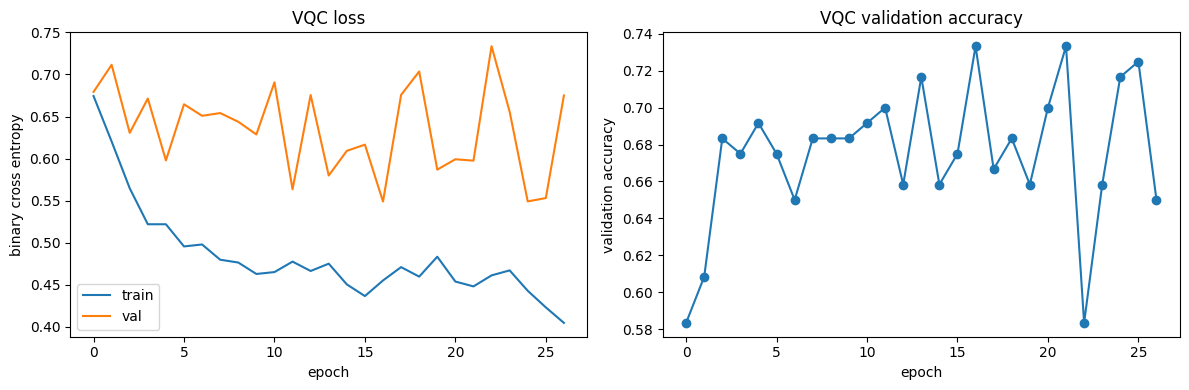

In [47]:
benchmark = {
    'XGBoost (12 features)':           {'accuracy': float(xgb_full_acc), 'f1': float(xgb_full_f1), 'train_size': int(len(X_train_scaled))},
    'XGBoost (selected 4 features)':   {'accuracy': float(xgb_selected_acc), 'f1': float(xgb_selected_f1), 'train_size': int(len(X_train_scaled))},
    'LSTM (windowed, 12 features)':    {'accuracy': float(lstm_acc), 'f1': float(lstm_f1), 'train_size': int(len(X_train_seq))},
    'XGBoost (matched subsample)':     {'accuracy': float(xgb_matched_acc), 'f1': float(xgb_matched_f1), 'train_size': int(config['quantum_train_size'])},
    'Quantum Kernel SVM':              {'accuracy': float(qksvm_acc), 'f1': float(qksvm_f1), 'train_size': int(config['quantum_train_size'])},
    'VQC (re-uploading, 4 readouts)':  {'accuracy': float(vqc_acc), 'f1': float(vqc_f1), 'train_size': int(config['quantum_train_size'])},
}
benchmark_df = pd.DataFrame(benchmark).T
print(benchmark_df)

log_df = pd.DataFrame(training_log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log_df['epoch'], log_df['train_loss'], label='train')
axes[0].plot(log_df['epoch'], log_df['val_loss'], label='val')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('binary cross entropy')
axes[0].set_title('VQC loss')
axes[0].legend()
axes[1].plot(log_df['epoch'], log_df['val_acc'], marker='o')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('validation accuracy')
axes[1].set_title('VQC validation accuracy')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

In [48]:
def predict_pit_window(raw_features_12d):
    t_start = time.time()
    scaled = feature_scaler.transform(raw_features_12d.reshape(1, -1))
    selected = scaled[:, selected_idx]
    angles = features_to_angles(selected)
    x_t = torch.tensor(angles, dtype=torch.float64)
    with torch.no_grad():
        logit = circuit_logits(x_t, vqc_weights, vqc_input_scales, vqc_readout, vqc_bias).squeeze()
        pit_probability = torch.sigmoid(logit).item()
    latency_ms = (time.time() - t_start) * 1000
    return float(pit_probability), latency_ms

latency_samples = []
for x in X_test[:60]:
    _, ms = predict_pit_window(x)
    latency_samples.append(ms)

latency_samples = np.array(latency_samples)
print(f'inference latency over 60 samples')
print(f'mean {latency_samples.mean():.1f}ms, median {np.median(latency_samples):.1f}ms, p95 {np.percentile(latency_samples, 95):.1f}ms, max {latency_samples.max():.1f}ms')
print(f'fraction under 100ms: {(latency_samples < 100).mean() * 100:.1f}%')

inference latency over 60 samples
mean 18.3ms, median 17.8ms, p95 21.2ms, max 24.1ms
fraction under 100ms: 100.0%


In [57]:
from kaggle_secrets import UserSecretsClient

GROQ_API_KEY = UserSecretsClient().get_secret('GROQ_API_KEY').strip()
print(f'key in scope, length {len(GROQ_API_KEY)}, prefix {GROQ_API_KEY[:4]}')

groq_models = [
    'llama-3.3-70b-versatile',
    'llama-3.1-8b-instant',
    'gemma2-9b-it',
]

def call_groq(prompt, max_retries=2):
    headers = {
        'Authorization': f'Bearer {GROQ_API_KEY}',
        'Content-Type': 'application/json',
    }
    last_error = None
    for model_id in groq_models:
        for attempt in range(max_retries):
            response = requests.post(
                'https://api.groq.com/openai/v1/chat/completions',
                headers=headers,
                json={
                    'model': model_id,
                    'messages': [{'role': 'user', 'content': prompt}],
                    'max_tokens': 250,
                    'temperature': 0.3,
                },
                timeout=45,
            )
            if response.status_code == 200:
                return response.json()['choices'][0]['message']['content'], model_id
            last_error = f'{response.status_code} on {model_id}: {response.text[:150]}'
            if response.status_code == 429:
                time.sleep(2 ** attempt)
                continue
            break
    return f'all models exhausted, last error: {last_error}', None

def generate_strategy_explanation(features_dict, pit_probability):
    prompt = (
        f"You are an F1 race strategist. A quantum ML model has produced a {pit_probability:.1%} "
        f"probability that this driver will pit within the next {config['pit_horizon_laps']} laps, "
        f"given the lap telemetry below.\n\n"
        f"Telemetry:\n{json.dumps({k: round(float(v), 3) for k, v in features_dict.items()}, indent=2)}\n\n"
        "In three sentences: name the dominant signal driving this read, recommend pit, stay out, or monitor, "
        "and flag the main downside of acting on this call."
    )
    return call_groq(prompt)

ping = requests.post(
    'https://api.groq.com/openai/v1/chat/completions',
    headers={'Authorization': f'Bearer {GROQ_API_KEY}', 'Content-Type': 'application/json'},
    json={
        'model': 'llama-3.3-70b-versatile',
        'messages': [{'role': 'user', 'content': 'ping'}],
        'max_tokens': 5,
    },
    timeout=30,
)
print(f'groq auth test status {ping.status_code}')

for i in range(3):
    x = X_test[i]
    prob, ms = predict_pit_window(x)
    feats = dict(zip(feature_cols, x))
    print(f'sample {i}: pit_probability {prob:.3f}, true label {y_test[i]}, inference {ms:.1f}ms')
    text, model_used = generate_strategy_explanation(feats, prob)
    if model_used:
        print(f'[via {model_used}]')
    print(text)
    print()

key in scope, length 56, prefix gsk_
groq auth test status 200
sample 0: pit_probability 0.413, true label 0, inference 20.3ms
[via llama-3.3-70b-versatile]
The dominant signal driving the 41.3% probability of pitting within the next 2 laps is the tyre life, which is at 14.0, indicating that the tyres are nearing the end of their lifespan, combined with a pace drop of 0.134 seconds over the last 3 laps. Based on this data, I recommend to monitor the driver's pace and tyre life closely, as pitting now may not be necessary given the relatively stable position and gap to the leader, but staying out for too long may lead to a significant loss of pace. The main downside of acting on this call and pitting now is that it may put the driver in a difficult position to regain their current position, especially if the leader and other competitors do not pit at the same time, potentially losing valuable track position.

sample 1: pit_probability 0.167, true label 1, inference 18.7ms
[via llama-3.3

In [60]:
from kaggle_secrets import UserSecretsClient

OPENROUTER_API_KEY = UserSecretsClient().get_secret('OPENROUTER_API_KEY').strip()
print(f'key in scope, length {len(OPENROUTER_API_KEY)}, prefix {OPENROUTER_API_KEY[:8]}')

fallback_models = [
    'meta-llama/llama-3.2-3b-instruct:free',
    'google/gemma-2-9b-it:free',
    'mistralai/mistral-7b-instruct:free',
    'meta-llama/llama-3.3-70b-instruct:free',
]

def call_openrouter(prompt, max_retries=2):
    headers = {
        'Authorization': f'Bearer {OPENROUTER_API_KEY}',
        'Content-Type': 'application/json',
        'HTTP-Referer': 'https://github.com',
        'X-Title': 'F1 QML Pit Strategy',
    }
    last_error = None
    for model_id in fallback_models:
        for attempt in range(max_retries):
            response = requests.post(
                'https://openrouter.ai/api/v1/chat/completions',
                headers=headers,
                json={
                    'model': model_id,
                    'messages': [{'role': 'user', 'content': prompt}],
                    'max_tokens': 250,
                    'temperature': 0.3,
                },
                timeout=45,
            )
            if response.status_code == 200:
                return response.json()['choices'][0]['message']['content'], model_id
            last_error = f'{response.status_code} on {model_id}: {response.text[:150]}'
            if response.status_code == 429:
                time.sleep(2 ** attempt)
                continue
            break
    return f'all free models exhausted, last error: {last_error}', None

def generate_strategy_explanation(features_dict, pit_probability):
    prompt = (
        f"You are an F1 race strategist. A quantum ML model has produced a {pit_probability:.1%} "
        f"probability that this driver will pit within the next {config['pit_horizon_laps']} laps, "
        f"given the lap telemetry below.\n\n"
        f"Telemetry:\n{json.dumps({k: round(float(v), 3) for k, v in features_dict.items()}, indent=2)}\n\n"
        "In three sentences: name the dominant signal driving this read, recommend pit, stay out, or monitor, "
        "and flag the main downside of acting on this call."
    )
    text, model_used = call_openrouter(prompt)
    return text, model_used

for i in range(3):
    x = X_test[i]
    prob, ms = predict_pit_window(x)
    feats = dict(zip(feature_cols, x))
    print(f'sample {i}: pit_probability {prob:.3f}, true label {y_test[i]}, inference {ms:.1f}ms')
    text, model_used = generate_strategy_explanation(feats, prob)
    if model_used:
        print(f'[via {model_used}]')
    print(text)
    print()

key in scope, length 73, prefix sk-or-v1
sample 0: pit_probability 0.413, true label 0, inference 19.8ms
all free models exhausted, last error: 429 on meta-llama/llama-3.3-70b-instruct:free: {"error":{"message":"Provider returned error","code":429,"metadata":{"raw":"meta-llama/llama-3.3-70b-instruct:free is temporarily rate-limited upstrea

sample 1: pit_probability 0.167, true label 1, inference 20.0ms
all free models exhausted, last error: 429 on meta-llama/llama-3.3-70b-instruct:free: {"error":{"message":"Provider returned error","code":429,"metadata":{"raw":"meta-llama/llama-3.3-70b-instruct:free is temporarily rate-limited upstrea

sample 2: pit_probability 0.302, true label 1, inference 21.3ms
all free models exhausted, last error: 429 on meta-llama/llama-3.3-70b-instruct:free: {"error":{"message":"Provider returned error","code":429,"metadata":{"raw":"meta-llama/llama-3.3-70b-instruct:free is temporarily rate-limited upstrea

